In [2]:
import random
import matplotlib.pyplot as plt

# Given initial population (same as assignment)
population = [
    "00101",
    "01011",
    "10100",
    "11110",
    "01101",
    "10010"
]

# Parameters
BITS = 5
PC = 0.8   # Crossover probability
PM = 0.1   # Mutation probability

In [3]:
def decode(chromosome):
    dv = int(chromosome, 2)   # binary → decimal
    x = -5 + (10/31) * dv     # formula
    return dv, x

In [4]:
def fitness(x):
    return x ** 2

In [5]:
evaluated = []

print("Initial Population:\n")

for chrom in population:
    dv, x = decode(chrom)
    fx = fitness(x)
    
    evaluated.append({
        "chrom": chrom,
        "dv": dv,
        "x": x,
        "fx": fx
    })
    
    print(f"{chrom} → x={round(x,3)} → f(x)={round(fx,3)}")

Initial Population:

00101 → x=-3.387 → f(x)=11.472
01011 → x=-1.452 → f(x)=2.107
10100 → x=1.452 → f(x)=2.107
11110 → x=4.677 → f(x)=21.878
01101 → x=-0.806 → f(x)=0.65
10010 → x=0.806 → f(x)=0.65


In [6]:
def tournament_selection(data):
    a = random.choice(data)
    b = random.choice(data)
    
    return a if a["fx"] < b["fx"] else b


mating_pool = []

print("\nTournament Selection:\n")

for i in range(6):
    winner = tournament_selection(evaluated)
    mating_pool.append(winner["chrom"])
    print(f"Selected: {winner['chrom']}")


Tournament Selection:

Selected: 10100
Selected: 10100
Selected: 01011
Selected: 10100
Selected: 01101
Selected: 01101


In [7]:
offspring = []

print("\nCrossover:\n")

for i in range(0, 6, 2):
    p1 = mating_pool[i]
    p2 = mating_pool[i+1]
    
    if random.random() < PC:
        cut = random.randint(1, BITS-1)
        
        c1 = p1[:cut] + p2[cut:]
        c2 = p2[:cut] + p1[cut:]
        
        print(f"{p1} + {p2} → {c1}, {c2}")
        
        offspring.extend([c1, c2])
    else:
        offspring.extend([p1, p2])


Crossover:

10100 + 10100 → 10100, 10100
01011 + 10100 → 00100, 11011
01101 + 01101 → 01101, 01101


In [8]:
def mutate(chrom):
    new_chrom = ""
    
    for bit in chrom:
        if random.random() < PM:
            new_chrom += '1' if bit == '0' else '0'
        else:
            new_chrom += bit
    
    return new_chrom


mutated = []

print("\nMutation:\n")

for chrom in offspring:
    m = mutate(chrom)
    print(f"{chrom} → {m}")
    mutated.append(m)


Mutation:

10100 → 00000
10100 → 10100
00100 → 00100
11011 → 11011
01101 → 11101
01101 → 01101


In [9]:
combined = population + mutated

all_data = []

for chrom in combined:
    dv, x = decode(chrom)
    fx = fitness(x)
    all_data.append((chrom, dv, x, fx))

# Sort by fitness
all_data.sort(key=lambda x: x[3])

next_gen = all_data[:6]

print("\nNext Generation:\n")

for item in next_gen:
    print(f"{item[0]} → x={round(item[2],3)} → f(x)={round(item[3],3)}")


Next Generation:

01101 → x=-0.806 → f(x)=0.65
10010 → x=0.806 → f(x)=0.65
01101 → x=-0.806 → f(x)=0.65
10100 → x=1.452 → f(x)=2.107
10100 → x=1.452 → f(x)=2.107
01011 → x=-1.452 → f(x)=2.107



Best Initial: {'chrom': '01101', 'dv': 13, 'x': -0.806451612903226, 'fx': 0.6503642039542147}
Best Next: ('01101', 13, -0.806451612903226, 0.6503642039542147)


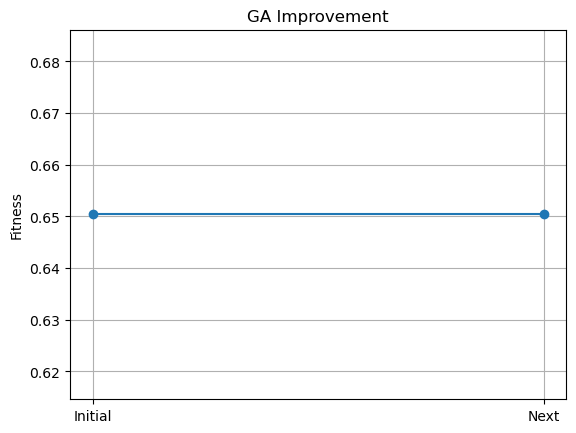

In [10]:
initial_best = min(evaluated, key=lambda x: x["fx"])
next_best = min(next_gen, key=lambda x: x[3])

print("\nBest Initial:", initial_best)
print("Best Next:", next_best)

# Plot
plt.plot([0,1], [initial_best["fx"], next_best[3]], marker='o')
plt.xticks([0,1], ["Initial", "Next"])
plt.title("GA Improvement")
plt.ylabel("Fitness")
plt.grid()
plt.show()